In [17]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import os
import gdown

In [8]:
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)
FOLDER_ID = "1yB-LBqkj3-SD8gyznsZ4H0tWkfIonk7E"
if not os.listdir(DATA_DIR):
    url = f"https://drive.google.com/drive/folders/{FOLDER_ID}"
    gdown.download_folder(url, output=DATA_DIR, quiet=False)    

Retrieving folder contents


Processing file 11iwEyCNB8_getsAp3umcMkpKhwuJUVOs mnist_test.csv
Processing file 1O1caz_Jv0CJuqlJzkEC09DhzjWn0de0L mnist_train.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=11iwEyCNB8_getsAp3umcMkpKhwuJUVOs
To: /Users/par_04/code_playground/ml/Linkedin_projects/ML/data/mnist_test.csv
100%|██████████| 18.3M/18.3M [00:01<00:00, 12.1MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1O1caz_Jv0CJuqlJzkEC09DhzjWn0de0L
From (redirected): https://drive.google.com/uc?id=1O1caz_Jv0CJuqlJzkEC09DhzjWn0de0L&confirm=t&uuid=07be95f8-3f2a-4b3d-aeb3-9f4ba9ca3813
To: /Users/par_04/code_playground/ml/Linkedin_projects/ML/data/mnist_train.csv
100%|██████████| 110M/110M [00:07<00:00, 14.6MB/s] 
Download completed


In [10]:
train_data= pd.read_csv("data/mnist_train.csv")
test_data=pd.read_csv("data/mnist_test.csv")

In [ ]:
X_train=train_data.iloc[:,1:785].values
y_train=train_data.iloc[:,0].values
X_test=test_data.iloc[:,1:785].values
y_test=test_data.iloc[:,0].values

In [13]:
X_train=X_train/255
X_test=X_test/255

In [14]:
num_classes = 10
n_train=y_train.shape[0]
classes =10
Y_train=np.zeros((n_train,classes))
for i in range(0, n_train, 1):
    Y_train[i][y_train[i]]=1

In [15]:
num_classes = 10
n_test=y_test.shape[0]
classes =10
Y_test=np.zeros((n_test,classes))
for i in range(0, n_test, 1):
    Y_test[i][y_test[i]]=1

In [ ]:
print("choose your activation fucntion:")
print("0.Linear")
print("2.ReLU")
print("4.ELU")
print("5.leaky ReLU")

choose your activation fucntion:
0.Linear
2.ReLU
4.ELU
5.leaky ReLU


In [ ]:
f=X_train.shape[1]
layers=[f]
W=[]
B=[]
funcs=[]
lay=int(input(f"enter the number of layers in the NN except the Softmax"))
for i in range(lay):
    choice=int(input("enter the activation function for this layer"))
    if choice==4:
        alpha=int(input("enter alpha"))
        funcs.append([choice,alpha])
    else:
        funcs.append([choice,None])
    neurons=int(input(f"enter the number of neurons in layer {i+1}"))
    layers.append(neurons)
    B.append(np.zeros((1,neurons)))
for i in range(lay):
    lim=np.sqrt(2/(layers[i]))
    w=np.random.normal(0,lim,size=(layers[i],layers[i+1]))
    W.append(w)

In [ ]:
import matplotlib.pyplot as plt
import random
class NN:
    def __init__(self,input_matrix,ground_truth,Weights, Bias,Activations,batch_size,epochs=1000 ,learning_rate=2e-3):
        self.epochs=epochs
        self.lr=learning_rate
        self.X=input_matrix     #must be a (n,784)..
        self.Y=ground_truth     #must be (n,classes)..
        self.W=Weights
        self.B=Bias
        Activations.append([-1,None])
        self.acts=Activations
        self.bs=batch_size
        self.n=input_matrix.shape[0]
        self.Z=[]
        self.A=[]
        self.accuracy=0
        self.batches_list=[(i, min(i+self.bs-1, self.n)) for i in range(0, self.n, self.bs)]
        for i in self.batches_list:
            if i[1]-i[0] < self.bs -1 :
                self.batches_list.pop()

        start = (self.n // self.bs) * self.bs
        self.remaineder = (start, self.n) if self.n % self.bs != 0 else None    
        random.shuffle(self.batches_list)
        self.avg_losses=[]
        if(self.remaineder):
                self.n=self.n + 1
        self.train_acc=[]
        self.test_acc=[]   
    
    # leaky RELU
    def leaky_RELU(self,arr):
        arr=np.asarray(arr)
        return np.maximum(0.1*arr, arr)
    #Linear
    def linear(self,arr):
        arr=np.asarray(arr)
        return arr 
    #Relu
    def ReLU(self,arr):
        arr=np.asarray(arr)
        return np.maximum(0, arr) 
    #softmax
    def softmax(self,logits):
        sub=np.max(logits,axis=1)
        return np.exp(logits- np.reshape(sub, (-1,1)))/np.reshape(np.sum(np.exp(logits- np.reshape(sub, (-1,1))), axis=1), (-1,1))
    
    def FWD(self, x):#logits returns 
        self.A=[]
        self.Z=[]
        act=x
        self.A.append(act)
        for i in range(len(self.W)-1):
            z=act@self.W[i]+self.B[i]
            self.Z.append(z)
            if self.acts[i][0]==0:
                act=self.linear(z)
            elif self.acts[i][0]==1:
                act=self.sigmoid(z)
            elif self.acts[i][0]==2:
                act=self.ReLU(z)
            elif self.acts[i][0]==3:   
                act=self.tanh(z)
            elif self.acts[i][0]==4:
                act=self.ELU(z,self.acts[i][1])
            elif self.acts[i][0]==5:
                act=self.leaky_RELU(z)
            self.A.append(act)
        act=act@self.W[len(self.W)-1]+self.B[len(self.W)-1]
        self.A.append(act)
        return act  #logits

    def prob(self, logits):# returns probab
        return self.softmax(logits)
        
    def BACK(self,xin,y_batch, num):
        correct=0
        n = xin.shape[0]
        pred=self.prob(self.FWD(xin))          
        dZ=pred- y_batch
        signal= dZ

        dW=(1/n)*self.A[len(self.W)-1].T@ signal           #calcs
        dB=(1/n)*np.sum(signal,axis=0, keepdims=True)    #calcs

        signal=signal @ self.W[len(self.W)-1].T    #signal passing

        self.B[len(self.W)-1]-=self.lr*dB       #updations
        self.W[len(self.W)-1]-=self.lr*dW       #updation

        for i in range(len(self.W)-1,0,-1):
            if self.acts[i-1][0]==0:#Linear
                fun_term=np.ones_like(self.Z[i-1])  #same size matrix with 1s

            elif self.acts[i-1][0]==1:  #Sigmoid
                fun_term=(self.A[i]*(1-self.A[i]))

            elif self.acts[i-1][0]==2:  #ReLU
                fun_term=(self.Z[i-1]>0).astype(float)  #imp its a matrix   <vectorized output>
                    
            elif self.acts[i-1][0]==3:   #tanh
                fun_term=1-(self.A[i])**2

            elif self.acts[i-1][0]==4:  # ELU 
                alpha=self.acts[i-1][1]
                fun_term=np.where(self.Z[i-1]>0,1,alpha*np.exp(self.Z[i-1])).astype(float)       # if this condn holds, <put this value>, else put <this >.  #imp its a matrix. <vectorized output>

            elif self.acts[i-1][0]==5: #Leaky ELU
                fun_term=np.where(self.Z[i-1]>0,1,0.1).astype(float)    #imp its a matrix     <vectorized output>

            signal=signal*fun_term  #       activation derivtive
            
            dW=(1/n)*self.A[i-1].T@signal      #take the avg across all the rows
            dB=(1/n)*np.sum(signal,axis=0, keepdims=True)    #take the avg across the rows   
            
            signal=signal @ self.W[i-1].T     #signal passing

            self.B[i-1]-=self.lr*dB             #updations
            self.W[i-1]-=self.lr*dW            #updations
                     
        return self.CE(pred,y_batch)
    
    def CE(self, prob,y_batch):
        prob=np.clip(prob, 1e-15, 1)
        return -np.mean(np.sum(y_batch*(np.log(prob)), axis=1))
    
    def train(self):
        for epoch in tqdm(range(self.epochs)):
            tqdm.write(f"\t\tEpoch : {epoch+1}\n")
            if epoch % 5 ==0:
                self.lr*=0.5
            batch=0
            sum_loss=0
            for batch in range(len(self.batches_list)):
                num = batch
                x=self.X[self.batches_list[batch][0] : self.batches_list[batch][1]+1]
                y=self.Y[self.batches_list[batch][0] : self.batches_list[batch][1]+1]
                L=self.BACK(x,y, num)
                sum_loss+=L
                if (epoch+1)%5==0 and batch %100==0 :
                    print(f" Epoch : {epoch+1} Batch number : {batch+1} \n Current Loss:{L:.5f}\n")
            if(self.remaineder):
                x_rem=self.remaineder
                rem=x_rem[1]-x_rem[0]+1
                x=self.X[x_rem[0] : x_rem[1]]
                y=self.Y[x_rem[0] : x_rem[1]]
                L=self.BACK(x,y, batch +1)
                sum_loss+=L
            self.avg_losses.append((epoch+1,sum_loss/len(self.batches_list)))
            if (epoch+1)%5 ==0 and batch %100 ==0:
                print(f"Epoch : {epoch+1} \n ** LAST REMAINDER BATCH  of {rem} elements\nCurrent Loss:{L:.5f}")
                print(f"Epoch : {epoch+1} \navg loss= {(L/self.n)}\n\n")
                          
    def pred(self,x):
        act=x
        for i in range(len(self.W)-1):
            z=act@self.W[i]+self.B[i]
            if self.acts[i][0]==0:
                act=self.linear(z)
            elif self.acts[i][0]==1:
                act=self.sigmoid(z)
            elif self.acts[i][0]==2:
                act=self.ReLU(z)
            elif self.acts[i][0]==3:   
                act=self.tanh(z)
            elif self.acts[i][0]==4:
                act=self.ELU(z,self.acts[i][1])
            elif self.acts[i][0]==5:
                act=self.leaky_RELU(z)
        logits=act@self.W[len(self.W)-1]+self.B[len(self.W)-1]
        pred=self.prob(logits)
        idx=int(np.argmax(pred))      
        maxi_probab=pred[0,idx]
        return (idx,maxi_probab)

    def test(self, x, y):
        correct=0
        n=y.shape[0]
        preds = []
        for row in x:
            idx, prob = self.pred(row)
            p = np.zeros(y.shape[1])
            p[idx] = prob
            preds.append(p)

        preds = np.array(preds)
        preds= np.clip(preds, 1e-15, 1)

        loss = -np.mean(np.sum(y * np.log(preds), axis=1))
        for i in range(y.shape[0]):
            if np.argmax(y[i]) == np.argmax(preds[i]):
                correct+=1
        print(f"TEST LOSS: {loss}")
        print(f"TEST ACCURACY: {correct/n*100}%")

    def plot_train_vs_loss(self):
        epochs = [x[0] for x in self.avg_losses]
        losses = [x[1] for x in self.avg_losses]
        plt.figure(figsize=(12,8))
        plt.title("Training Loss vs Epochs")
        plt.plot(epochs, losses, color="green", marker="s", markersize=5, label="Training Loss", linestyle='--')
        plt.grid()
        plt.legend(loc="best")
        plt.xlabel("Epochs")
        plt.ylabel("Avg Loss of batches per epoch")
        plt.show()
    

    

In [16]:
# 	1.	Accuracy vs Epoch
# 	2.	Confusion Matrix
# 	3.	Sample Predictions (correct + wrong)
# 	4.	Loss vs Accuracy (dual plot)
# 	5.	Confidence Distribution (max softmax probs)
# 	6.	Learning Rate vs Loss (if tuning LR)

In [ ]:
model=NN(X_train,Y_train,W,B,funcs,64,epochs=20,learning_rate=0.003)

In [ ]:
model.train()

  0%|          | 0/20 [00:00<?, ?it/s]

		Epoch : 1



  5%|▌         | 1/20 [00:03<01:01,  3.25s/it]

		Epoch : 2



 10%|█         | 2/20 [00:06<00:56,  3.16s/it]

...

		Epoch : 19



 95%|█████████▌| 19/20 [00:53<00:03,  3.01s/it]

		Epoch : 20

 Epoch : 20 Batch number : 1 
 Current Loss:0.04223

 Epoch : 20 Batch number : 101 
 Current Loss:0.02426

 Epoch : 20 Batch number : 201 
 Current Loss:0.01786

 Epoch : 20 Batch number : 301 
 Current Loss:0.04400

 Epoch : 20 Batch number : 401 
 Current Loss:0.03104

 Epoch : 20 Batch number : 501 
 Current Loss:0.02432

 Epoch : 20 Batch number : 601 
 Current Loss:0.03089

 Epoch : 20 Batch number : 701 
 Current Loss:0.01604

 Epoch : 20 Batch number : 801 
 Current Loss:0.02808



100%|██████████| 20/20 [00:56<00:00,  2.82s/it]

 Epoch : 20 Batch number : 901 
 Current Loss:0.01963



In [ ]:
model.test(X_test, Y_test)

TEST LOSS: 0.9420796014275679
TEST ACCURACY: 97.32973297329734%


In [ ]:
x=[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,149,193,5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,91,224,253,253,19,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,28,235,254,253,253,166,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,144,253,254,253,253,253,238,115,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,31,241,253,208,185,253,253,253,231,24,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,79,254,193,0,8,98,219,254,255,201,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,86,253,80,0,0,0,182,253,254,191,12,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,175,253,155,0,0,0,234,253,254,135,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,86,253,208,40,85,166,251,237,254,236,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,18,238,253,254,253,253,185,36,216,253,152,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68,240,255,254,145,8,0,134,254,223,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,68,158,142,12,0,0,9,175,253,161,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,88,253,226,18,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,166,253,126,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,48,245,253,38,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,115,254,172,9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,21,218,254,46,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,254,165,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,186,244,42,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,223,78,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]
x=np.asarray(x)
x=x.reshape(1,-1)

In [ ]:
prediction=model.pred(x)

In [ ]:
prediction[1]

np.float64(1.0)

In [ ]:
prediction[0]    

9

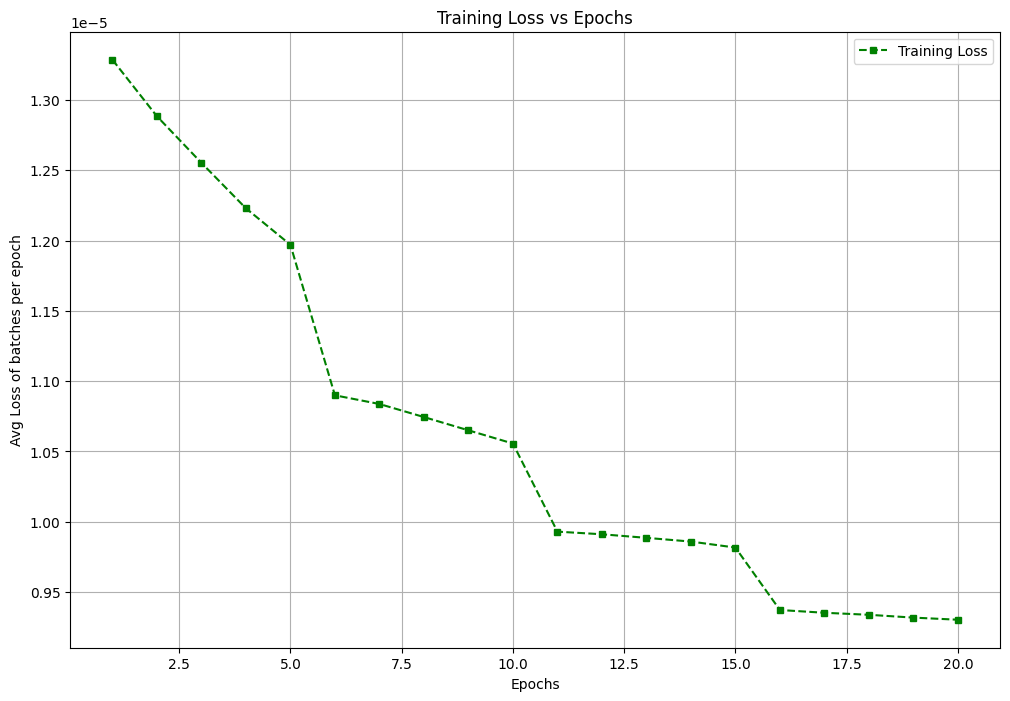

In [ ]:
model.plot_train_vs_loss()

In [1]:
import numpy as np
arr = np.array([[1, 2], [3, 4], [5, 6]])
np.random.shuffle(arr) # The array 'arr' is now shuffled


In [2]:
arr

array([[5, 6],
       [1, 2],
       [3, 4]])